In [1]:
import json
import os 
import torch
import sys 
sys.path.insert(0, "/root/userfolder/MIL/VL-MIL")
from mil.builder import create_model, save_model, create_aggregator
from mil.losses import LOSS_DICT
from mil.train.utils import (
    visualize_errors, 
    print_metrics,
    print_label_metrics, 
    specificity_precision_recall_f1_auc_acc,
    entropy_based_fusion,
    entropy_weights_from_logits
)
from mil.data.data_components import last_token
from mil.visualize.utils import visualize_instance_weights, visualize_instance

from pathlib import Path
import argparse

/root/userfolder/anaconda3/envs/mil/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/root/userfolder/anaconda3/envs/mil/lib/python3.10/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/root/userfolder/anaconda3/envs/mil/lib/python3.10/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The '

In [2]:
from mil.data.vlmil_dataset import DualModalNeonatalFundusDataset
example_path = "/root/commonfile/NFI/jsons/examples/examples.json"
dataset = DualModalNeonatalFundusDataset([example_path], tokens='image', layer=23)
image_root = "/root/commonfile/InfantVQA/nfi/images"
label_list = ["NEG", "RH", "ROP", "WS"]

[Dataset] Loading dataset from /root/commonfile/NFI/jsons/examples/examples.json
[Dataset] Successfully loaded 4 samples from /root/commonfile/NFI/jsons/examples/examples.json


In [3]:
import torch.nn as nn 
from typing import Optional
from mil.constants import ENCODER_DIM_MAPPING 

class GVLMIL(nn.Module):
    def __init__(self, config=None, ckpt_path=None):
        super().__init__()
        # load from checkpoint
        if ckpt_path is not None:
            print("Load GVL-MIL")
            with open(os.path.join(ckpt_path, 'training_args.json'), 'r') as f:
                config_json = json.load(f)
            self.config = argparse.Namespace(**config_json)
        else:
            print("Create GVL-MIL")
            self.config = config
        
        # print(self.config.loss)
        if ckpt_path is not None:
            directory = Path(ckpt_path)
            # 只返回直接子目录名
            folders = [item.name for item in directory.iterdir() if item.is_dir()]
            if len(folders) > 0:
                weight_path = folders[0]
            self.loss_fn = LOSS_DICT[self.config.loss]
            img_mil_path = os.path.join(ckpt_path, weight_path, 'image_mil', 'model.safetensors')
            text_mil_path = os.path.join(ckpt_path, weight_path, 'text_mil', 'model.safetensors')
            agg_path = os.path.join(ckpt_path, weight_path, 'aggregator.pth')
            from_pretrained = True
        else:
            img_mil_path, text_mil_path, agg_path = "", "", ""
            self.loss_fn = nn.CrossEntropyLoss()
            from_pretrained = False

        # load checkpoints
        self.aggregator = create_aggregator('xattn', self.config.encoder)
        if os.path.isfile(agg_path) and agg_path.endswith('.pth'):
            agg_ckpt = torch.load(agg_path)
            self.aggregator.load_state_dict(agg_ckpt)

        # load dual-branch mil
        mil_name = ".".join([self.config.mil_name, self.config.cfg_name, self.config.encoder])
        self.image_mil = create_model(
            mil_name, num_classes=self.config.num_labels, 
            checkpoint_path=img_mil_path, 
            from_pretrained=from_pretrained,
            keep_classifier=True
            )
        self.text_mil = create_model(
            mil_name, num_classes=self.config.num_labels, 
            checkpoint_path=text_mil_path, 
            from_pretrained=from_pretrained, 
            keep_classifier=True)
        
    def forward(
            self, 
            image_features: torch.Tensor, 
            text_features: torch.Tensor, 
            labels: torch.LongTensor, 
            masks: Optional[torch.Tensor] = None, 
            visualize: Optional[bool] = False
        ):
        assert image_features.shape[-1] == ENCODER_DIM_MAPPING[self.config.encoder]
        assert text_features.shape[-1] == ENCODER_DIM_MAPPING[self.config.encoder]
        if image_features.ndim == 3:
            image_features = image_features.unsqueeze(0)
        if text_features.ndim == 2:
            text_features = text_features.unsqueeze(0)

        # print(image_features.shape, text_features.shape)

        # an image is represented by a feature map rather than a vector
        if image_features.ndim == 4:
            # todo: add aggregator
            if image_features.shape[-2] > 1:
                if self.aggregator is not None:
                    image_features, token_attn = self.aggregator(image_features, instance_mask=masks, visualize=visualize)
                else:
                    image_features = image_features[:,:,-1,:]
            elif image_features.shape[-2] == 1:
                image_features = image_features.squeeze(-2)
        
        # print(image_features.shape, text_features.shape)
        # print(labels.shape)
        
        if self.config.fusion != 'feature':
            outputs1 = self.image_mil(image_features, self.loss_fn, labels, masks, return_attention=visualize)
            outputs2 = self.text_mil(text_features, self.loss_fn, labels, masks, return_attention=visualize)
            logits1, logits2 = outputs1[0]['logits'], outputs2[0]['logits']
            loss = outputs1[0]['loss'] + outputs2[0]['loss']
            weights = entropy_weights_from_logits([logits1, logits2])
            w1 = weights[:, 0].unsqueeze(-1)  # (B, 1)
            w2 = weights[:, 1].unsqueeze(-1)  # (B, 1)
            logits = logits1 * w1 + logits2 * w2 

        # print(outputs2)
        outputs = {"logits": logits, "loss": loss}
        if visualize:
            outputs['weights'] = {'image': w1, "text": w2}
            outputs['attention'] = {'image': outputs1[0]['attention'], 'text': outputs2[0]['attention']}   
            outputs['token attention'] = token_attn       

        return outputs
    
ckpt_path = "/root/userfolder/data-ckpts/VL-MIL/checkpoints/v2/mil_weights/main_ours/dsmil-0"
model = GVLMIL(ckpt_path=ckpt_path)

Load GVL-MIL


/root/userfolder/MIL/VL-MIL/mil/builder/ModelDict.py:193: UserWarning: Pretrained flag is True, but task is set to 'none'. Using random weights
  warnings.warn("Pretrained flag is True, but task is set to 'none'. Using random weights")
2025-11-21 16:50:40.222 | WARNING  | mil.builder:_update_checkpoint_path:107 - Checkpoint path manually provided (/root/userfolder/data-ckpts/VL-MIL/checkpoints/v2/mil_weights/main_ours/dsmil-0/15Epoch/image_mil/model.safetensors). Overwriting previous local filepath /root/userfolder/data-ckpts/VL-MIL/checkpoints/v2/mil_weights/dsmil.base.qwen2-7b.none.
2025-11-21 16:50:40.251 | INFO     | mil.builder.builder_utils:load_pretrained:316 - Loading pretrained weights from file (/root/userfolder/data-ckpts/VL-MIL/checkpoints/v2/mil_weights/main_ours/dsmil-0/15Epoch/image_mil/model.safetensors)
2025-11-21 16:50:40.253 | INFO     | mil.builder.builder_utils:load_state_dict:136 - Loaded  from checkpoint '/root/userfolder/data-ckpts/VL-MIL/checkpoints/v2/mil_weig

"Model name dsmil.base.qwen2-7b does not have a task, using default task none.
"Model name dsmil.base.qwen2-7b does not have a task, using default task none.


===================NEG exsample===================


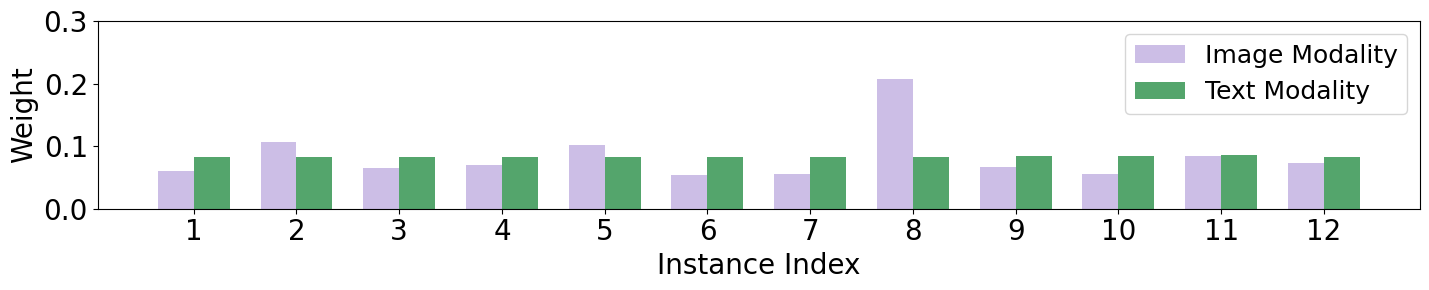

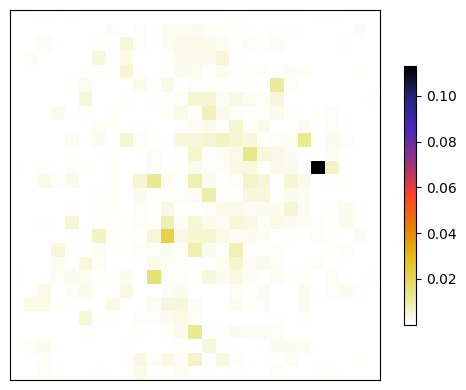

===================RH exsample====================


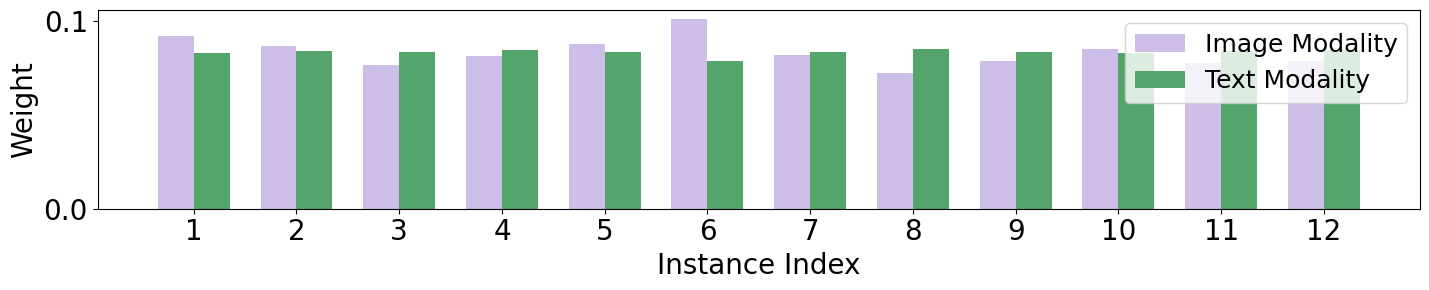

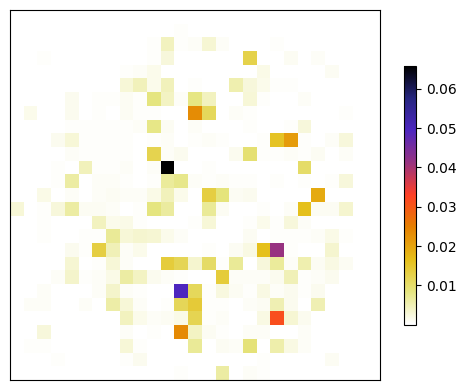

===================ROP exsample===================


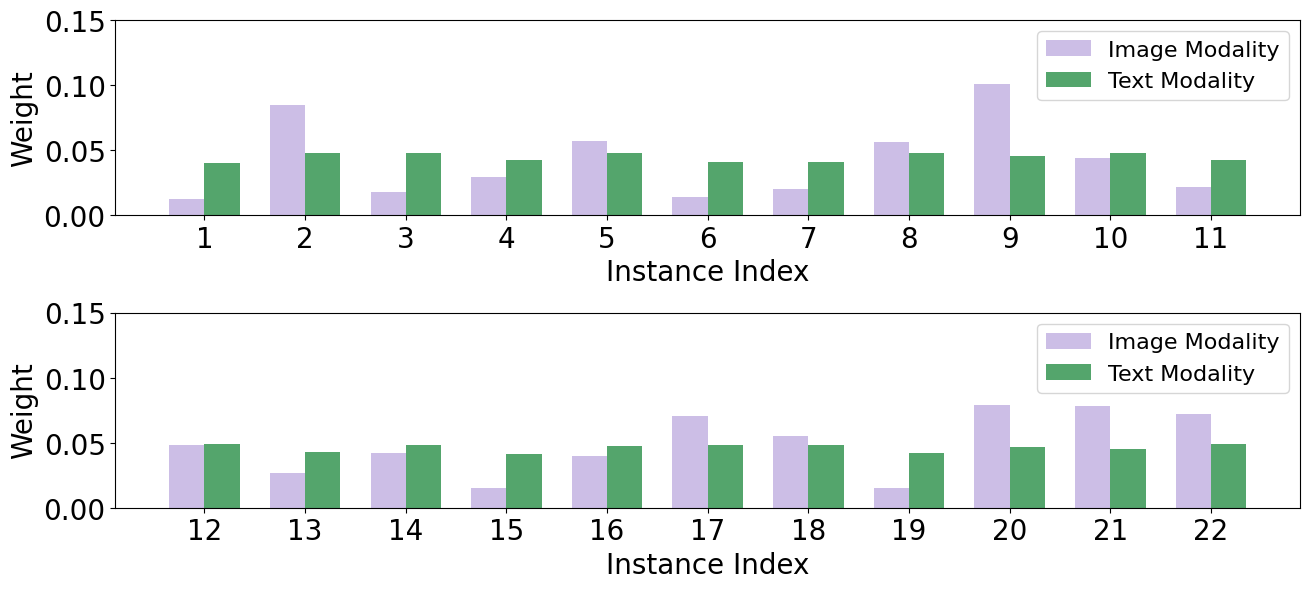

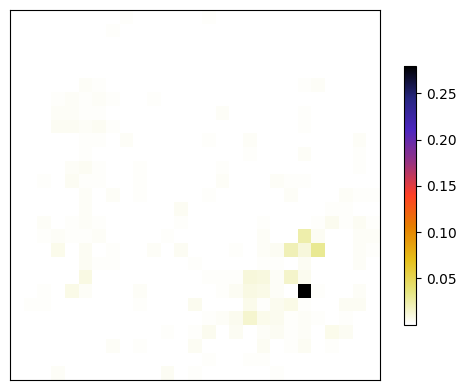

===================WS exsample====================


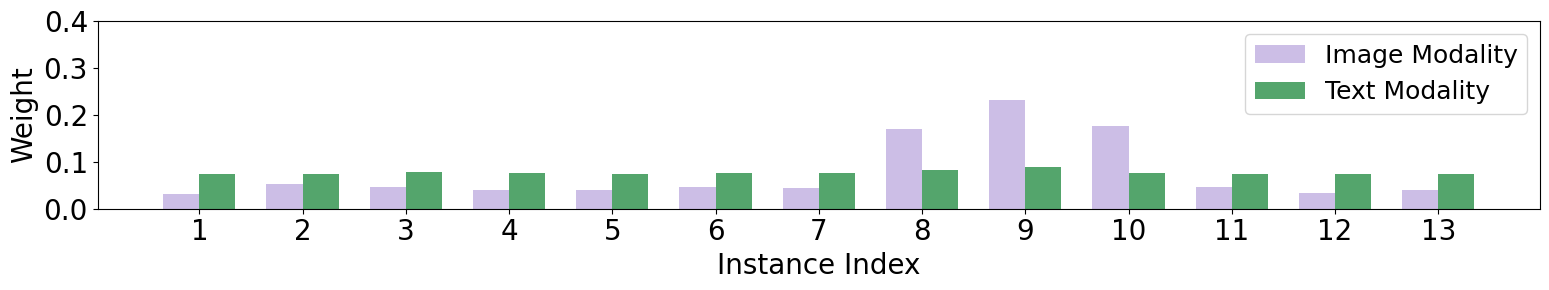

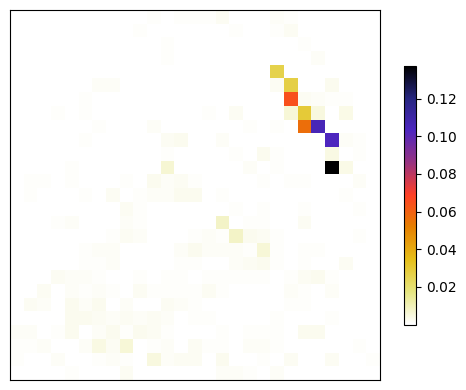

In [8]:
# examples = [dataset[323], dataset[1400], dataset[1700], dataset[1801]]
model.eval()

with torch.inference_mode():
    for sample in dataset:
        print("="*60)
        print(f"{label_list[sample['label']]} exsample")
        print("-"*60)

        label = label_list[sample['label']]
        # print(sample['id'], sample['patient'])
        image_features = sample['input_features'].float()
        text_features = last_token(sample['output_features']).float()
        labels = torch.tensor([sample['label']]).long()
        max_K = text_features.shape[0]
        arange_K = torch.arange(max_K).unsqueeze(0)
        masks = (arange_K < max_K).float()
        # print(labels, torch.argmax(model(image_features, text_features, labels, masks)[0], dim=1))
        # print(labels, model(image_features, text_features, labels, masks))
        outputs = model(image_features, text_features, labels, masks, visualize=True)
        # print(outputs['token attention'].shape)
        token_attention = outputs['token attention']
        # print(outputs["logits"])
        # pred = int(torch.argmax(outputs["logits"], dim=1))
        pred = torch.argmax(outputs["logits"], dim=1)
        # print(pred)
        # print(pred, outputs['attention']['image'][0,:,pred])
        
        # image_list
        patient_folder = os.path.join(image_root, sample['patient'])
        images_list = sorted(os.listdir(patient_folder), key = lambda x: int(x.split('.')[-2]))
        # print(images_list)
        images_list = [os.path.join(patient_folder, path) for path in images_list]
        # print(outputs['attention']['image'][0,:,pred].shape)
        visualize_instance_weights(images_list, outputs['attention']['image'],  outputs['attention']['text'], pred, title=f"{label_list[int(pred)]} sample weights")
        selected_idx = torch.argmax(outputs['attention']['image'][0,:,pred], dim=0)
        # selected_idx = 0
        # print(selected_idx, images_list[selected_idx].split("/")[-1])
        visualize_instance(token_attention, selected_idx, title=label + " instance heatmap")
        # visualize_instance(token_attention, image_path=images_list[selected_idx], instance_idx=selected_idx, title=(label + " instance heatmap"))

In [5]:
outputs['token attention'].shape

torch.Size([1, 13, 729])